## Introduction to nptsne

This Jupyter notebook provides an executable documentation for using the nptsne package. To run it install nptsne from Pypi or pip install the downloaded .whl file fo your os. 

#### Demo requirements

This version o fnptsne is supported on python 3.9, 3.10, 3.11, 3.12 and 3.13. The following packages are required to run this demo:

* numpy
* matplotlib
* six
* scipy
* umap-learn (for the umap examples)


In [1]:
import os
import sys
import nptsne
import matplotlib.pyplot as plt
from   matplotlib import rc
import numpy as np
import umap

from six.moves import urllib
from scipy.io import loadmat
from matplotlib import colors as mcolors
from timeit import default_timer as timer
colors = ['#FF0000', '#FF9900', '#CCFF00', '#33FF00', '#00FF66', '#00FFFF', '#0066FF', '#3300FF', '#CC00FF', '#FF0099']
print("Running python {}.{}".format(sys.version_info.major, sys.version_info.minor))


D:\TempProj\nptsne\demos\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running python 3.13


### <font color=blue>nptsne.TextureTsne API</font>

This class allows a basic inteface which is similar to the [scikit-learn tsne](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html). This API comprises the following methods 
* `__init__`: nptsne.TextureTsne() constructor
* `fit_transform` : Create the tSNE embedding

Full API documentation will be shown in the cell below.

In [2]:
import nptsne
help(nptsne)


Help on package nptsne:

NAME
    nptsne - A numpy compatible python extension for GPGPU linear complexity t-SNE and HSNE

DESCRIPTION
    This package contains classes that wrap linear complexity *t-SNE*
    and classes to support *HSNE*.

    Available subpackages
    ---------------------

    hsne_analysis
       Provides classes for selection driven navigation of the HSNE model and mapping back
       to the original data. The classes are intended to support visual analytics

    Notes
    -----
    :class:`ndarray` types are the preferred parameters types for input
    and where possible internal data in the wrapped t-SNE [1]_ and HSNE [2]_ is returned without
    a copy in a :class:`ndarray`.

    References
    ----------
    .. [1] Pezzotti, N. et al., `GPGPU Linear Complexity t-SNE Optimization <https://doi.org/10.1109/TVCG.2019.2934307>`_
    .. [2] Pezzotti, N. et al., `Hierarchical Stochastic Neighbor Embedding <https://doi.org/10.1111/cgf.12878>`_

PACKAGE CONTENTS
    ex

In [3]:
from nptsne import KnnAlgorithm
help(KnnAlgorithm)

Help on class KnnAlgorithm in module nptsne.libs._nptsne:

class KnnAlgorithm(pybind11_builtins.pybind11_object)
 |  Method resolution order:
 |      KnnAlgorithm
 |      pybind11_builtins.pybind11_object
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __and__(...)
 |      __and__(self: object, other: object) -> object
 |
 |  __eq__(...)
 |      __eq__(self: object, other: object) -> bool
 |
 |  __ge__(...)
 |      __ge__(self: object, other: object) -> bool
 |
 |  __getstate__(...)
 |      __getstate__(self: object) -> int
 |
 |  __gt__(...)
 |      __gt__(self: object, other: object) -> bool
 |
 |  __hash__(...)
 |      __hash__(self: object) -> int
 |
 |  __index__(...)
 |      __index__(self: nptsne.libs._nptsne.KnnAlgorithm) -> int
 |
 |  __init__(...)
 |      __init__(self: nptsne.libs._nptsne.KnnAlgorithm, value: int) -> None
 |
 |  __int__(...)
 |      __int__(self: nptsne.libs._nptsne.KnnAlgorithm) -> int
 |
 |  __invert__(...)
 |      __invert__(self: object) -> o

#### <font color=blue>Download minist data for use in the demos</font>

In [4]:
from pathlib import Path
root = Path.cwd().resolve().parent
mnist_path = root / 'data/mnist-original.mat'
#if not os.path.isfile(mnist_path):
#    mnist_alternative_url = 'https://github.com/amplab/datascience-sp14/raw/master/lab7/mldata/mnist-original.mat'
#    response = urllib.request.urlopen(mnist_alternative_url)
#    with open(mnist_path, 'wb') as f:
#        content = response.read()
#        f.write(content)
mnist_raw = loadmat(mnist_path)
mnist = {
    'data': mnist_raw['data'].T,
    'label': mnist_raw['label'][0],
    'COL_NAMES': ['label', 'data']
}
print('Mnist data dimenstions: ', mnist['data'].shape)


Mnist data dimenstions:  (70000, 784)


#### <font color=blue>Create a tSNE embedding of the 70000 MNIST data points & display the elapsed time</font>

In [5]:
tsne = nptsne.TextureTsne(False,1000,2,30,800, nptsne.KnnAlgorithm.Flann)
#Can also be run with knn as HNSW: this works faster in very large datasets lower dimensional data (<40 dimensions)
#tsne = nptsne.TextureTsne(False,1000,2,30,800, nptsne.nptsne.KnnAlgorithm.HNSW)

embedding = None
try:
   
    for i in range(1):
        start = timer()
        embedding = tsne.fit_transform(mnist['data'])
        end = timer()
        print(f'got embedding in {end - start}')
except Exception as ex:
    print('Error....')
    print(ex)

got embedding in 12.359275099996012


#### <font color=blue>Display the tSNE Mnist embedding</font>

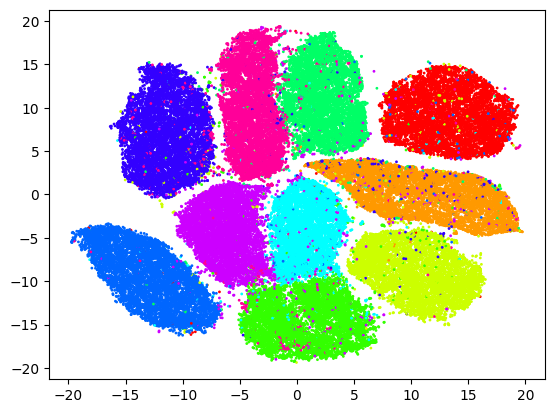

In [6]:
# norm = mcolors.Normalize(vmin=0, vmax=9)
xyembed = embedding.reshape((70000, 2))
# mcolors.ListedColormap(colors)
rc('lines', linewidth=2)
rc('lines', markersize=1)
plt.scatter(xyembed[..., 0], xyembed[..., 1], c=mnist['label'], cmap=mcolors.ListedColormap(colors), marker='o')
plt.show()

### <font color=blue>nptsne.TextureTsneExtended API</font>

This class offers a second, more flexible API. It adds a number of features to the basic TextureTsne API, specifically:

* `__init`: nptsne.TextureTsneExtended() constructor.
* `init_transform`: Initialize the transform with data and an optional initial embedding.  Performs the nearest neighbor calculation
* `run_transform`: Running/restarting the transform for a number or iterations (enables display of intermediate results). Enable/disable verbose output. 
* `start_exaggeration_decay`: Explicitly triggering the force exaggeration decay. Permits the typical tSNE cluster expansion. In the basic API this occurs at 250 iterations.
* `close`: Free the GPU resources.

Properties
* `decay_started_at`: The iteration number when decay exaggeration was started.
* `iteration_count`: The current iteration.

Full API documentation will be shown in the cell below.

In [7]:
print("nptsne version: {}".format(nptsne.__version__))
help(nptsne.TextureTsneExtended)

nptsne version: 2.0.0a2
Help on class TextureTsneExtended in module nptsne.libs._nptsne:

class TextureTsneExtended(pybind11_builtins.pybind11_object)
 |  Create an extended functionality wrapper for the linear tSNE implementation.
 |
 |  Parameters
 |  ----------
 |  verbose : bool
 |      Enable verbose logging to standard output, default is False
 |  num_target_dimensions : int
 |      The number of dimensions for the output embedding. Default is 2.
 |  perplexity : int
 |      The tSNE parameter that defines the neighborhood size. Usually between 10 and 30. Default is 30.
 |  knn_algorithm : :class:`KnnAlgorithm`
 |      The knn algorithm used for the nearest neighbor calculation. The default is 'Flann' for less than 50 dimensions 'HNSW' may be faster
 |  knn_metric : :class:`KnnDistanceMetric`
 |      The knn distance metric used for the nearest neighbor calculation.
 |      The default is `KnnDistanceMetric.Euclidean` the only supported metric for `Flann`
 |
 |  Attributes
 |  --

#### <font color=blue>Create and initialize TextureTsneExtended with Mnist data</font>

In [8]:
tsne = nptsne.TextureTsneExtended(False)
embeddings = []
if tsne.init_transform(mnist['data']):
    print('Init succeeded')

Init succeeded


#### <font color=blue>Run the tSNE embedding in blocks of 100 iterations. Reduce the exaggeration force from step 700. Record the intermediate embeddings in a plot.</font>

got embedding in 1.8682141000026604
iteration count 100
subplot 1
got embedding in 0.17864109999209177
iteration count 200
subplot 2
got embedding in 0.18570810000528581
iteration count 300
subplot 3
got embedding in 0.19389150000642985
iteration count 400
subplot 4
got embedding in 0.20346589999098796
iteration count 500
subplot 5
got embedding in 0.21154899999964982
iteration count 600
subplot 6
got embedding in 0.2266014000051655
iteration count 700
subplot 7
exaggeration stopping at 700
got embedding in 0.23925009999948088
iteration count 800
subplot 8
got embedding in 0.3292284000053769
iteration count 900
subplot 9
got embedding in 0.47121979999064934
iteration count 1000
subplot 10


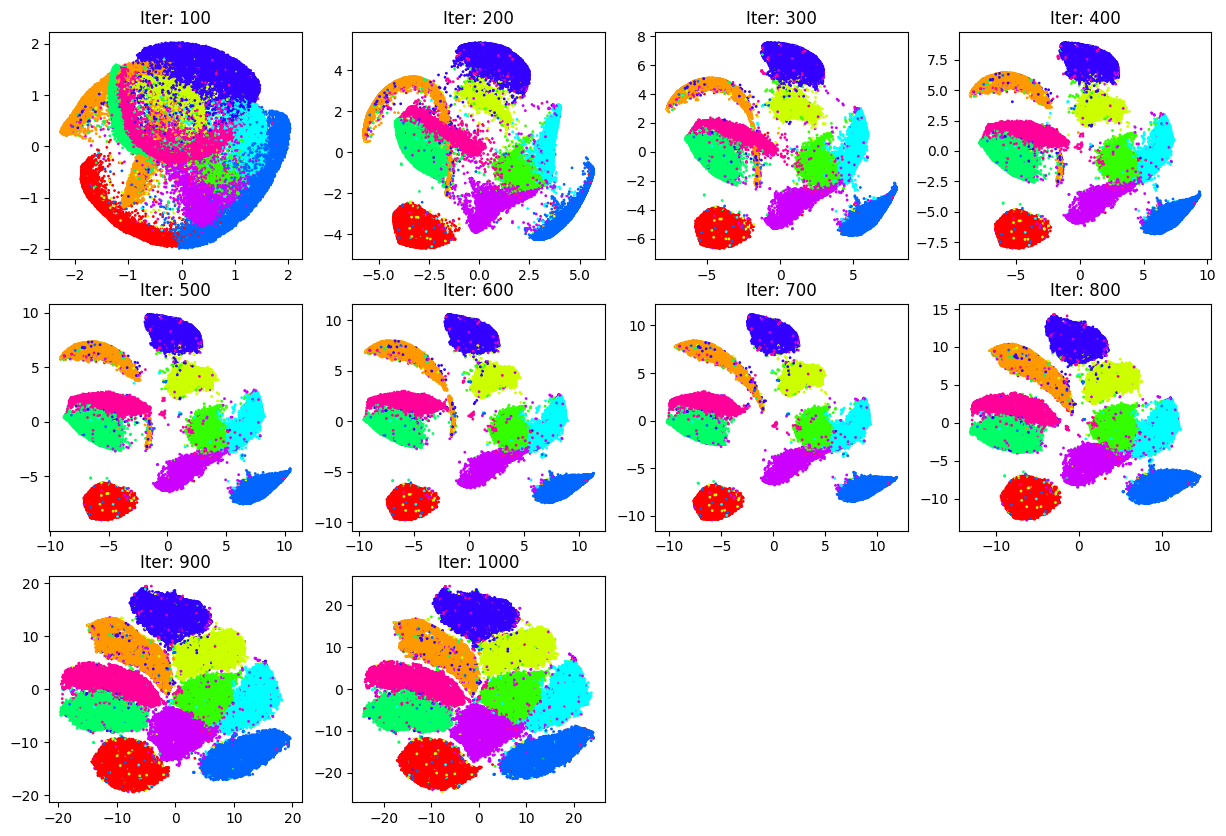

In [9]:
step_size = 100
plt.figure(2,figsize=(15,10))

for i in range(10):
    
    start = timer()
    stop_exaggeration = False
    # reduce the forces from iteration 700 
    if i == 7:
        tsne.start_exaggeration_decay()
        print(f'exaggeration stopping at {tsne.decay_started_at}')
    embedding = tsne.run_transform(verbose=False, iterations=step_size)
    end = timer()
    print(f'got embedding in {end - start}')
    print(f'iteration count {tsne.iteration_count}')
    xyembed = np.copy(embedding.reshape((70000, 2)))
    embeddings.append(xyembed)
    print(f"subplot {i+1}")
    plt.subplot(3,4,i+1)
    plt.gca().set_title('Iter: ' + str(100*(i+1)))
    plt.scatter(xyembed[..., 0], xyembed[..., 1], c=mnist['label'], cmap=mcolors.ListedColormap(colors), marker='o')

plt.draw()
plt.savefig(f'testext.png')
   


#### <font color=blue>Reset the embedding and rerun the transform above. This does not rerun the knn so the speed of the OpenGL texture speed is clear.</font>

Rerun the cell below (using Ctrl-Enter) to demonstrate the stochastic nature of the embedding

Recalculated embedding in 2.6934474000008777


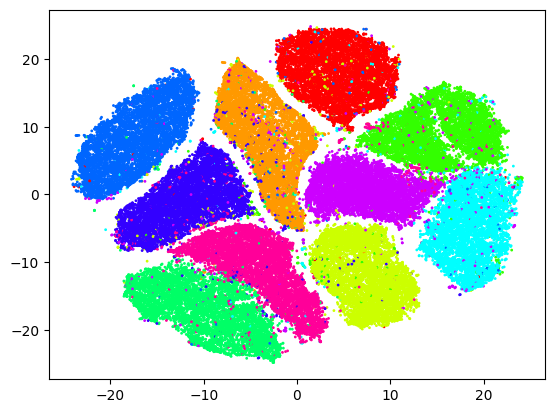

In [10]:
fig, axes = plt.subplots()
tsne.reinitialize_transform()
start = timer()
tsne.run_transform(verbose=False, iterations=700)
tsne.start_exaggeration_decay()
embedding = tsne.run_transform(verbose=False, iterations=300)
end = timer()
print(f'Recalculated embedding in {end - start}')
xyembed = np.copy(embedding.reshape((70000, 2)))
embeddings.append(xyembed)
axes.scatter(xyembed[..., 0], xyembed[..., 1], c=mnist['label'], cmap=mcolors.ListedColormap(colors), marker='o')

#### <font color=blue>Closing the tsne frees the OpenGL context</font>

In [11]:
tsne.close() 

#### <font color=blue>Make a umap embedding of a randompy selected 1/10 of the Mnist data.</font>

(6972,) (6972, 784)


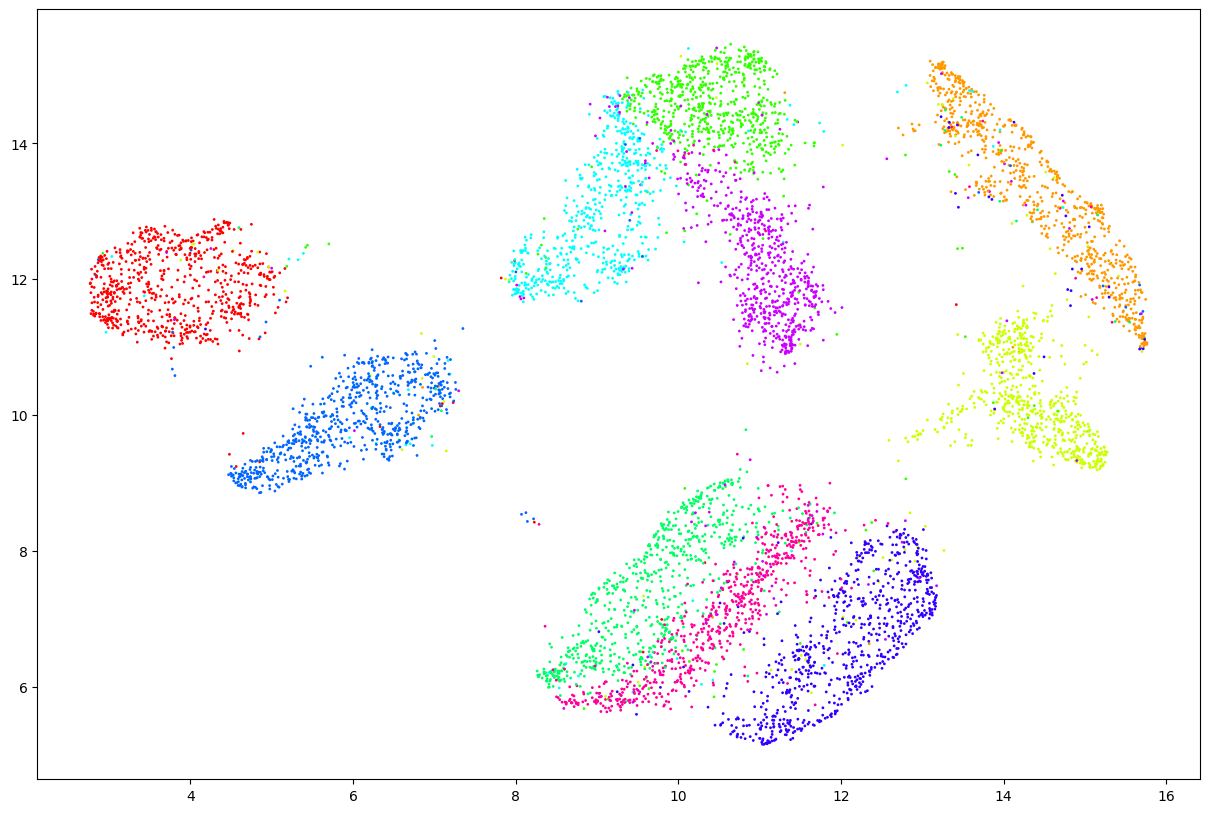

In [12]:
# extract 1 data point in 10  : p=[.1, .9]
# generate and index array with approximately 1/10 of data row numbers
import umap
idx = np.where(np.random.choice([1, 0], size=70000, p=[0.1, 0.9]))
subLabel = np.squeeze(mnist['label'][idx])
subData =  mnist['data'][idx]

print(subLabel.shape, subData.shape)

umap_embed = umap.UMAP().fit_transform(subData)

plt.figure(3,figsize=(15,10))

plt.scatter(umap_embed[..., 0], umap_embed[..., 1], c=subLabel, cmap=mcolors.ListedColormap(colors), marker='o')
plt.draw()


#### <font color=blue>Use the umap embedding to initialize the TextureTsneExtended. 

This shows that with high exaggeration forces tSNE leaves the umap embedding largely unchanged. Allowing the exaggeration forces to decay produced a more typical tSNE embedding.</font>

This equivalence has been noted elsewhere see [Attraction-Repulsion Spectrum in Neighbor Embeddings](https://arxiv.org/abs/2007.08902) 

Init tSNE from umap, shape: (6972, 2)
Init from umap succeeded
got embedding in 0.4522362999996403
got embedding in 0.0624007000005804
got embedding in 0.06312940000498202
got embedding in 0.05232679999608081
got embedding in 0.05778229999123141
exaggeration stopping at 500
got embedding in 0.05918289998953696
got embedding in 0.07594979999703355
got embedding in 0.09667499999341089
got embedding in 0.09760729999106843
got embedding in 0.09571940000751056


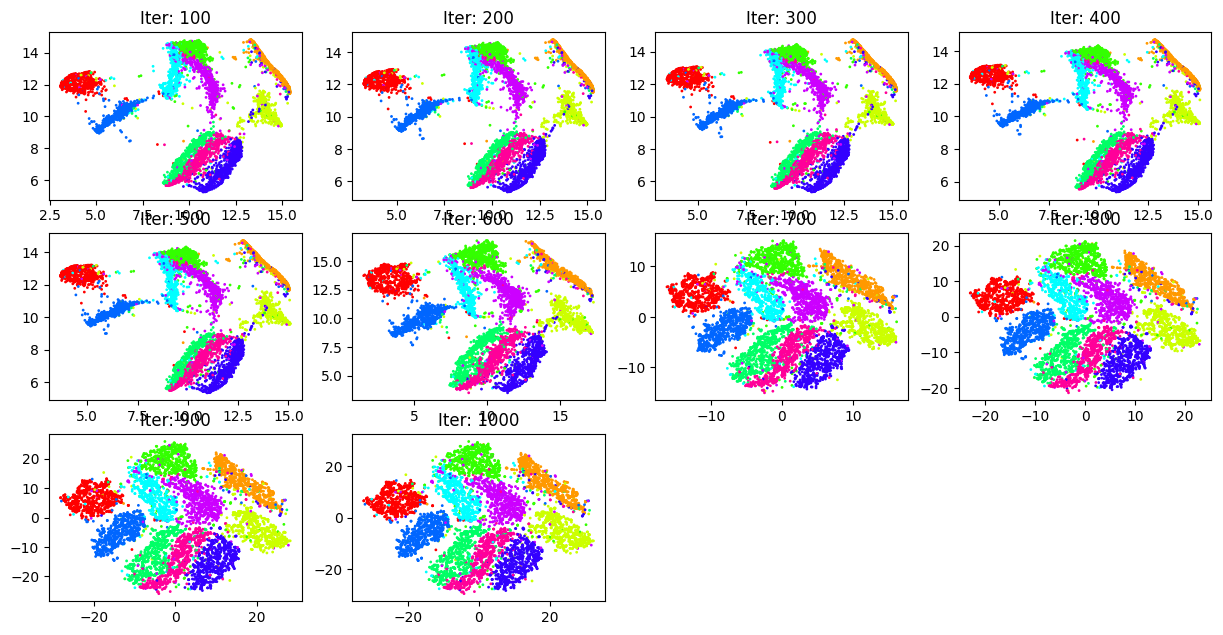

In [13]:
tsne = nptsne.TextureTsneExtended(verbose=True)

print(f'Init tSNE from umap, shape: {umap_embed.shape}')
if tsne.init_transform(subData, umap_embed):
    print('Init from umap succeeded')

step_size = 100
plt.figure(4,figsize=(15,10))
for i in range(10):
    start = timer()
    exaggeration_iter = 100
    # reduce the forces from 1000 
    if i == 5:
        tsne.start_exaggeration_decay()
        print(f'exaggeration stopping at {tsne.decay_started_at}')

    embedding = tsne.run_transform(verbose=True, iterations=step_size)
    end = timer()
    print(f'got embedding in {end - start}')
    xyembed = np.copy(embedding.reshape((-1, 2)))
    plt.subplot(4,4,i+1)
    plt.gca().set_title('Iter: ' + str(100*(i+1)))
    plt.scatter(xyembed[..., 0], xyembed[..., 1], c=subLabel, cmap=mcolors.ListedColormap(colors), marker='o')

plt.draw()

tsne.close()  
